# imports

In [40]:
import pandas as pd
import seaborn as sns
import numpy as np

## pull data

In [3]:
path = r'C:\Projects\Statbotics\RomiRotem\data\datasets\full_table2.csv'

df = pd.read_csv(path)

In [4]:
df

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
0,1.742056e+09,f,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",blue,...,True,False,False,True,0.0,0.0,frc2783,124.0,1,red
1,1.742058e+09,f,2025alhu,2025alhu_f1m2,2,1.742058e+09,1,1.742057e+09,"[{'key': '1FpcfKgS3kw', 'type': 'youtube'}]",blue,...,True,True,True,False,0.0,0.0,frc2783,144.0,1,red
2,1.741960e+09,qm,2025alhu,2025alhu_qm1,1,1.741960e+09,1,1.741960e+09,"[{'key': 'mAbsfvQlhaw', 'type': 'youtube'}]",red,...,False,False,False,False,5.0,2.0,frc5045,129.0,1,red
3,1.741965e+09,qm,2025alhu,2025alhu_qm10,10,1.741965e+09,1,1.741965e+09,"[{'key': 'xrkAU-qZY-E', 'type': 'youtube'}]",red,...,True,True,True,True,1.0,0.0,frc538,112.0,1,red
4,1.741965e+09,qm,2025alhu,2025alhu_qm11,11,1.741965e+09,1,1.741965e+09,"[{'key': 'ae-lJ4geVPg', 'type': 'youtube'}]",blue,...,False,True,True,True,1.0,1.0,frc6107,61.0,1,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116377,1.752379e+09,sf,2025xxmel,2025xxmel_sf5m1,1,1.752379e+09,5,1.752378e+09,[],red,...,False,False,False,False,6.0,0.0,frc9995,64.0,3,blue
116378,1.752379e+09,sf,2025xxmel,2025xxmel_sf6m1,1,1.752379e+09,6,1.752379e+09,[],blue,...,False,False,False,False,1.0,0.0,frc9991,72.0,3,blue
116379,1.752380e+09,sf,2025xxmel,2025xxmel_sf7m1,1,1.752380e+09,7,1.752380e+09,[],red,...,False,False,False,False,0.0,0.0,frc9994,65.0,3,blue
116380,1.752380e+09,sf,2025xxmel,2025xxmel_sf8m1,1,1.752380e+09,8,1.752381e+09,[],red,...,False,True,True,True,14.0,0.0,frc9993,73.0,3,blue


# sum data

In [5]:
df.head(1)

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
0,1.742056e+09,f,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",blue,...,True,False,False,True,0.0,0.0,frc2783,124.0,1,red


In [6]:
df['autoLine'] = df['autoLine'].map({'Yes': True, 'No': False})

In [7]:
num_bool_cols = ['score', 'autoLine', 'autoReef_tba_botRowCount', 'autoReef_tba_midRowCount', 'autoReef_tba_topRowCount', 'autoReef_trough', 'foulCount', 'netAlgaeCount', 'techFoulCount', 'teleopReef_tba_botRowCount', 'teleopReef_tba_midRowCount', 'teleopReef_tba_topRowCount', 'teleopReef_trough', 'wallAlgaeCount']
cat_cols = ['endGame', 'possition']

In [ ]:
sdf = df.groupby('team_number').agg({
    **{col: 'mean' for col in num_bool_cols},
    **{col: lambda x: x.mode().iloc[0] for col in cat_cols},
    'key': lambda x: list(x.unique())
})

sdf.rename(columns={'key': 'games'}, inplace=True)

In [58]:
sdf.loc['frc2486']

score                                                                112.897959
autoLine                                                               0.969388
autoReef_tba_botRowCount                                               0.061224
autoReef_tba_midRowCount                                               0.030612
autoReef_tba_topRowCount                                               2.102041
autoReef_trough                                                        0.357143
foulCount                                                              0.173469
netAlgaeCount                                                          2.214286
techFoulCount                                                          0.459184
teleopReef_tba_botRowCount                                             2.397959
teleopReef_tba_midRowCount                                             4.295918
teleopReef_tba_topRowCount                                             8.438776
teleopReef_trough                       

In [14]:
sdf.loc['frc1574']

score                                                                129.340426
autoLine                                                                    1.0
autoReef_tba_botRowCount                                               0.021277
autoReef_tba_midRowCount                                               0.042553
autoReef_tba_topRowCount                                               3.531915
autoReef_trough                                                        0.319149
foulCount                                                              0.340426
netAlgaeCount                                                          1.638298
techFoulCount                                                          0.340426
teleopReef_tba_botRowCount                                             3.468085
teleopReef_tba_midRowCount                                             6.021277
teleopReef_tba_topRowCount                                             9.829787
teleopReef_trough                       

In [15]:
# sdf = pd.DataFrame()
# for team in df['team_number'].unique():
#     for col in num_bool_cols:
#         # print(col)
#         sdf.loc[team, col] = df.loc[df['team_number'] == team, col].mean()
#     for col2 in cat_cols:
#         sdf.loc[team, col2] = df.loc[df['team_number'] == team, col2].mode().iloc[0]
#     sdf['games'] = df.groupby('team_number')['key'].unique()

In [16]:
sdf

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,games
team_number,,,,,,,,,,,,,,,,,
frc1,86.321429,0.928571,0.000000,0.000000,1.214286,0.285714,0.142857,0.607143,0.178571,2.357143,2.750000,6.178571,2.571429,0.714286,Parked,1,"[2025miket_qm23, 2025miket_qm42, 2025misal_qm3..."
frc100,113.962963,1.000000,0.148148,0.074074,2.185185,0.296296,0.370370,1.962963,0.333333,2.888889,4.962963,8.444444,1.629630,0.925926,Parked,2,"[2025cafr_qm6, 2025cafr_qm75, 2025casj_qm4, 20..."
frc10000,82.375000,1.000000,0.125000,0.250000,0.625000,0.375000,0.500000,0.375000,2.500000,2.125000,2.875000,5.625000,1.125000,0.750000,Parked,2,"[2025cnsh_qm1, 2025cnsh_qm21, 2025cnsh_qm46, 2..."
frc10001,81.678571,0.964286,0.071429,0.000000,1.035714,0.892857,0.321429,1.178571,0.500000,1.214286,1.714286,5.785714,5.535714,0.678571,Parked,1,"[2025paphi_qm21, 2025paphi_qm32, 2025paphi_qm4..."
frc10002,94.303030,1.000000,0.030303,0.090909,0.848485,0.606061,0.424242,0.454545,0.303030,1.909091,2.272727,6.818182,3.484848,0.424242,Parked,3,"[2025ausc_qm10, 2025ausc_qm39, 2025ausc_qm53, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc9995,65.000000,0.882353,0.058824,0.000000,0.411765,1.176471,0.000000,0.294118,0.294118,2.764706,0.941176,3.294118,3.647059,0.235294,DeepCage,3,"[2025xxmel_qm30, 2025xxmel_qm40, 2025laman_sf5..."
frc9996,73.115385,0.769231,0.038462,0.000000,1.038462,0.423077,0.192308,1.307692,0.730769,1.692308,2.461538,4.115385,4.538462,0.307692,Parked,3,"[2025laman_sf5m1, 2025onsca1_qm22, 2025xxmel_q..."
frc9997,62.333333,0.666667,0.111111,0.000000,0.500000,0.166667,0.055556,1.444444,0.166667,0.833333,3.111111,4.833333,0.555556,0.500000,Nothing,1,"[2025laman_sf6m1, 2025wimc_qm1, 2025wimc_qm11,..."


In [17]:
sdf.loc['frc1574']

score                                                                129.340426
autoLine                                                                    1.0
autoReef_tba_botRowCount                                               0.021277
autoReef_tba_midRowCount                                               0.042553
autoReef_tba_topRowCount                                               3.531915
autoReef_trough                                                        0.319149
foulCount                                                              0.340426
netAlgaeCount                                                          1.638298
techFoulCount                                                          0.340426
teleopReef_tba_botRowCount                                             3.468085
teleopReef_tba_midRowCount                                             6.021277
teleopReef_tba_topRowCount                                             9.829787
teleopReef_trough                       

In [18]:
sdf.loc['frc1323']

score                                                                233.910714
autoLine                                                                    1.0
autoReef_tba_botRowCount                                               0.553571
autoReef_tba_midRowCount                                                    0.0
autoReef_tba_topRowCount                                               6.053571
autoReef_trough                                                        0.178571
foulCount                                                              0.267857
netAlgaeCount                                                             6.625
techFoulCount                                                          0.160714
teleopReef_tba_botRowCount                                             9.803571
teleopReef_tba_midRowCount                                            10.642857
teleopReef_tba_topRowCount                                            11.660714
teleopReef_trough                       

In [19]:
sdf.sort_values(by='score', ascending=False)

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,games
team_number,,,,,,,,,,,,,,,,,
frc1323,233.910714,1.000000,0.553571,0.000000,6.053571,0.178571,0.267857,6.625000,0.160714,9.803571,10.642857,11.660714,9.553571,1.089286,DeepCage,2,"[2025capt_qm37, 2025casj_f1m1, 2025casj_f1m2, ..."
frc2056,229.741573,1.000000,0.033708,0.292135,6.292135,0.191011,0.640449,7.741573,0.348315,9.730337,10.955056,11.404494,7.808989,1.056180,DeepCage,1,"[2025cmptx_sf4m1, 2025dal_qm91, 2025iri_qm47, ..."
frc2910,217.232877,1.000000,0.342466,0.849315,4.616438,0.287671,0.068493,5.424658,0.315068,9.383562,10.479452,11.191781,7.726027,1.178082,DeepCage,1,"[2025cmptx_sf11m1, 2025cmptx_sf13m1, 2025cmptx..."
frc1690,216.870588,1.000000,0.047059,0.082353,6.235294,0.258824,0.482353,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,DeepCage,2,"[2025iri_qm71, 2025iscmp_qm26, 2025iscmp_qm8, ..."
frc3276,206.904110,0.972603,0.054795,0.027397,3.780822,0.301370,0.178082,6.410959,0.273973,7.753425,10.000000,11.356164,5.109589,0.904110,DeepCage,2,"[2025iri_qm16, 2025iri_qm33, 2025mnmi2_f1m1, 2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc9185,32.875000,0.625000,0.000000,0.000000,0.125000,0.250000,0.750000,0.625000,6.000000,0.625000,0.375000,1.250000,1.000000,0.000000,Parked,1,"[2025tuis3_qm17, 2025tuis3_qm25, 2025tuis3_qm3..."
frc10531,32.111111,0.555556,0.111111,0.000000,0.111111,0.111111,1.333333,0.000000,2.000000,1.444444,0.666667,1.333333,0.555556,0.444444,Parked,1,"[2025tuis2_qm14, 2025tuis2_qm34, 2025tuis2_qm7..."
frc8898,32.000000,0.200000,0.000000,0.000000,0.000000,0.200000,0.400000,0.500000,0.700000,0.300000,0.800000,1.000000,4.200000,0.400000,Parked,2,"[2025cala_qm11, 2025cala_qm24, 2025cala_qm46, ..."


In [20]:
df.head(1)

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
0,1.742056e+09,f,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",blue,...,True,False,False,True,0.0,0.0,frc2783,124.0,1,red


## quality

In [21]:
#the scores of the teammates in an alliance
def teammate_scores (team_num, game_key):
   scores = []
   teammates = df.loc[(df['key'] == game_key) & (df['team_number'] != team_num) & (df['alliance'] == df.loc[(df['key'] == game_key) & (df['team_number'] == team_num), 'alliance'].iloc[0])]['team_number']
   for i in teammates:
      scores.append(float(sdf.at[i,'score']))
   return sum(scores)/len(scores)

In [22]:
#the average score of all teammates of team
def team_games(team_num):
    game_keys = df.loc[df['team_number'] == team_num]['key']
    averages = []
    for i in game_keys:
        averages.append(teammate_scores(team_num, i))
    
    return sum(averages)/len(averages)

In [24]:
team_quality_map = {team: float(sdf.at[team, 'score']) - team_games(team) for team in sdf.index}
sdf['quality'] = sdf.index.map(team_quality_map)

score                                                                216.870588
autoLine                                                                    1.0
autoReef_tba_botRowCount                                               0.047059
autoReef_tba_midRowCount                                               0.082353
autoReef_tba_topRowCount                                               6.235294
autoReef_trough                                                        0.258824
foulCount                                                              0.482353
netAlgaeCount                                                          5.270588
techFoulCount                                                          0.458824
teleopReef_tba_botRowCount                                             8.823529
teleopReef_tba_midRowCount                                             9.858824
teleopReef_tba_topRowCount                                            11.082353
teleopReef_trough                       

In [26]:
# for team in sdf.index:
#     sdf.at[team,'quality'] = float(sdf.at[team,'score']) - team_games(team)

In [28]:
sdf.to_csv(r"C:\Projects\Statbotics\RomiRotem\full_project\code\summery_df.csv", index=True)

In [29]:
path2 = r"C:\Projects\Statbotics\RomiRotem\full_project\code\summery_df.csv"

sdf = pd.read_csv(path2)

In [30]:
sdf.set_index(sdf.columns[0], inplace=True)
sdf.index.name = None

In [31]:
sdf

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,games,quality
frc1,86.321429,0.928571,0.000000,0.000000,1.214286,0.285714,0.142857,0.607143,0.178571,2.357143,2.750000,6.178571,2.571429,0.714286,Parked,1,"['2025miket_qm23', '2025miket_qm42', '2025misa...",-23.344473
frc100,113.962963,1.000000,0.148148,0.074074,2.185185,0.296296,0.370370,1.962963,0.333333,2.888889,4.962963,8.444444,1.629630,0.925926,Parked,2,"['2025cafr_qm6', '2025cafr_qm75', '2025casj_qm...",-0.361587
frc10000,82.375000,1.000000,0.125000,0.250000,0.625000,0.375000,0.500000,0.375000,2.500000,2.125000,2.875000,5.625000,1.125000,0.750000,Parked,2,"['2025cnsh_qm1', '2025cnsh_qm21', '2025cnsh_qm...",-23.040955
frc10001,81.678571,0.964286,0.071429,0.000000,1.035714,0.892857,0.321429,1.178571,0.500000,1.214286,1.714286,5.785714,5.535714,0.678571,Parked,1,"['2025paphi_qm21', '2025paphi_qm32', '2025paph...",-22.479647
frc10002,94.303030,1.000000,0.030303,0.090909,0.848485,0.606061,0.424242,0.454545,0.303030,1.909091,2.272727,6.818182,3.484848,0.424242,Parked,3,"['2025ausc_qm10', '2025ausc_qm39', '2025ausc_q...",13.843637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc9995,65.000000,0.882353,0.058824,0.000000,0.411765,1.176471,0.000000,0.294118,0.294118,2.764706,0.941176,3.294118,3.647059,0.235294,DeepCage,3,"['2025xxmel_qm30', '2025xxmel_qm40', '2025lama...",-11.357442
frc9996,73.115385,0.769231,0.038462,0.000000,1.038462,0.423077,0.192308,1.307692,0.730769,1.692308,2.461538,4.115385,4.538462,0.307692,Parked,3,"['2025laman_sf5m1', '2025onsca1_qm22', '2025xx...",-21.587643
frc9997,62.333333,0.666667,0.111111,0.000000,0.500000,0.166667,0.055556,1.444444,0.166667,0.833333,3.111111,4.833333,0.555556,0.500000,Nothing,1,"['2025laman_sf6m1', '2025wimc_qm1', '2025wimc_...",-38.470649
frc9998,52.526316,0.552632,0.078947,0.026316,0.473684,0.368421,0.184211,0.868421,1.131579,0.736842,1.000000,2.394737,3.289474,0.894737,Parked,1,"['2025caab_qm10', '2025caab_qm5', '2025laman_q...",-28.007808


In [32]:
float(sdf.at['frc1574','score']) - team_games('frc1574')

7.927856470025205

In [33]:
float(sdf.at['frc1580','score']) - team_games('frc1580')

-46.94625611668398

In [34]:
float(sdf.at['frc5135','score']) - team_games('frc5135')

-10.760674899848823

In [35]:
sdf

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,games,quality
frc1,86.321429,0.928571,0.000000,0.000000,1.214286,0.285714,0.142857,0.607143,0.178571,2.357143,2.750000,6.178571,2.571429,0.714286,Parked,1,"['2025miket_qm23', '2025miket_qm42', '2025misa...",-23.344473
frc100,113.962963,1.000000,0.148148,0.074074,2.185185,0.296296,0.370370,1.962963,0.333333,2.888889,4.962963,8.444444,1.629630,0.925926,Parked,2,"['2025cafr_qm6', '2025cafr_qm75', '2025casj_qm...",-0.361587
frc10000,82.375000,1.000000,0.125000,0.250000,0.625000,0.375000,0.500000,0.375000,2.500000,2.125000,2.875000,5.625000,1.125000,0.750000,Parked,2,"['2025cnsh_qm1', '2025cnsh_qm21', '2025cnsh_qm...",-23.040955
frc10001,81.678571,0.964286,0.071429,0.000000,1.035714,0.892857,0.321429,1.178571,0.500000,1.214286,1.714286,5.785714,5.535714,0.678571,Parked,1,"['2025paphi_qm21', '2025paphi_qm32', '2025paph...",-22.479647
frc10002,94.303030,1.000000,0.030303,0.090909,0.848485,0.606061,0.424242,0.454545,0.303030,1.909091,2.272727,6.818182,3.484848,0.424242,Parked,3,"['2025ausc_qm10', '2025ausc_qm39', '2025ausc_q...",13.843637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc9995,65.000000,0.882353,0.058824,0.000000,0.411765,1.176471,0.000000,0.294118,0.294118,2.764706,0.941176,3.294118,3.647059,0.235294,DeepCage,3,"['2025xxmel_qm30', '2025xxmel_qm40', '2025lama...",-11.357442
frc9996,73.115385,0.769231,0.038462,0.000000,1.038462,0.423077,0.192308,1.307692,0.730769,1.692308,2.461538,4.115385,4.538462,0.307692,Parked,3,"['2025laman_sf5m1', '2025onsca1_qm22', '2025xx...",-21.587643
frc9997,62.333333,0.666667,0.111111,0.000000,0.500000,0.166667,0.055556,1.444444,0.166667,0.833333,3.111111,4.833333,0.555556,0.500000,Nothing,1,"['2025laman_sf6m1', '2025wimc_qm1', '2025wimc_...",-38.470649
frc9998,52.526316,0.552632,0.078947,0.026316,0.473684,0.368421,0.184211,0.868421,1.131579,0.736842,1.000000,2.394737,3.289474,0.894737,Parked,1,"['2025caab_qm10', '2025caab_qm5', '2025laman_q...",-28.007808


In [36]:
sdf.sort_values(by = 'quality', ascending=False)

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,games,quality
frc1323,233.910714,1.000000,0.553571,0.000000,6.053571,0.178571,0.267857,6.625000,0.160714,9.803571,10.642857,11.660714,9.553571,1.089286,DeepCage,2,"['2025capt_qm37', '2025casj_f1m1', '2025casj_f...",87.361540
frc2056,229.741573,1.000000,0.033708,0.292135,6.292135,0.191011,0.640449,7.741573,0.348315,9.730337,10.955056,11.404494,7.808989,1.056180,DeepCage,1,"['2025cmptx_sf4m1', '2025dal_qm91', '2025iri_q...",87.308111
frc2910,217.232877,1.000000,0.342466,0.849315,4.616438,0.287671,0.068493,5.424658,0.315068,9.383562,10.479452,11.191781,7.726027,1.178082,DeepCage,1,"['2025cmptx_sf11m1', '2025cmptx_sf13m1', '2025...",79.624214
frc1690,216.870588,1.000000,0.047059,0.082353,6.235294,0.258824,0.482353,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,DeepCage,2,"['2025iri_qm71', '2025iscmp_qm26', '2025iscmp_...",75.592104
frc5940,202.666667,1.000000,0.117647,0.176471,4.823529,0.137255,0.509804,4.392157,0.313725,8.901961,10.294118,11.333333,3.647059,1.588235,DeepCage,1,"['2025casf_f1m1', '2025casf_f1m2', '2025casf_q...",70.442487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc3728,38.416667,0.000000,0.000000,0.000000,0.500000,0.166667,0.000000,1.333333,0.333333,0.833333,0.583333,2.083333,1.000000,0.333333,Nothing,1,"['2025txtom_qm24', '2025txtom_qm43', '2025txto...",-50.423504
frc6433,52.875000,0.750000,0.125000,0.125000,0.750000,0.125000,0.875000,0.375000,2.875000,1.000000,2.500000,2.625000,0.750000,0.375000,Nothing,1,"['2025cnsh_qm58', '2025cnsh_qm29', '2025cnsh_q...",-50.841273
frc6880,41.777778,0.444444,0.000000,0.222222,0.333333,0.444444,0.555556,0.555556,1.888889,1.000000,0.888889,2.666667,1.222222,0.333333,Nothing,1,"['2025nysu_qm28', '2025nysu_qm23', '2025nysu_q...",-51.850957
frc1761,55.208333,0.916667,0.083333,0.000000,0.375000,0.166667,0.166667,1.000000,1.166667,1.125000,0.833333,4.666667,0.791667,0.416667,Parked,1,"['2025mabos_qm54', '2025mabos_qm8', '2025nhsal...",-51.917867


In [37]:
sdf.sort_values(by = 'quality', ascending=True)

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,games,quality
frc8898,32.000000,0.200000,0.000000,0.000000,0.000000,0.200000,0.400000,0.500000,0.700000,0.300000,0.800000,1.000000,4.200000,0.400000,Parked,2,"['2025cala_qm11', '2025cala_qm24', '2025cala_q...",-54.348771
frc1761,55.208333,0.916667,0.083333,0.000000,0.375000,0.166667,0.166667,1.000000,1.166667,1.125000,0.833333,4.666667,0.791667,0.416667,Parked,1,"['2025mabos_qm54', '2025mabos_qm8', '2025nhsal...",-51.917867
frc6880,41.777778,0.444444,0.000000,0.222222,0.333333,0.444444,0.555556,0.555556,1.888889,1.000000,0.888889,2.666667,1.222222,0.333333,Nothing,1,"['2025nysu_qm28', '2025nysu_qm23', '2025nysu_q...",-51.850957
frc6433,52.875000,0.750000,0.125000,0.125000,0.750000,0.125000,0.875000,0.375000,2.875000,1.000000,2.500000,2.625000,0.750000,0.375000,Nothing,1,"['2025cnsh_qm58', '2025cnsh_qm29', '2025cnsh_q...",-50.841273
frc3728,38.416667,0.000000,0.000000,0.000000,0.500000,0.166667,0.000000,1.333333,0.333333,0.833333,0.583333,2.083333,1.000000,0.333333,Nothing,1,"['2025txtom_qm24', '2025txtom_qm43', '2025txto...",-50.423504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc5940,202.666667,1.000000,0.117647,0.176471,4.823529,0.137255,0.509804,4.392157,0.313725,8.901961,10.294118,11.333333,3.647059,1.588235,DeepCage,1,"['2025casf_f1m1', '2025casf_f1m2', '2025casf_q...",70.442487
frc1690,216.870588,1.000000,0.047059,0.082353,6.235294,0.258824,0.482353,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,DeepCage,2,"['2025iri_qm71', '2025iscmp_qm26', '2025iscmp_...",75.592104
frc2910,217.232877,1.000000,0.342466,0.849315,4.616438,0.287671,0.068493,5.424658,0.315068,9.383562,10.479452,11.191781,7.726027,1.178082,DeepCage,1,"['2025cmptx_sf11m1', '2025cmptx_sf13m1', '2025...",79.624214
frc2056,229.741573,1.000000,0.033708,0.292135,6.292135,0.191011,0.640449,7.741573,0.348315,9.730337,10.955056,11.404494,7.808989,1.056180,DeepCage,1,"['2025cmptx_sf4m1', '2025dal_qm91', '2025iri_q...",87.308111


In [38]:
sdf['quality'].describe()

count    3722.000000
mean       -8.062020
std        20.148338
min       -54.348771
25%       -22.478517
50%       -12.067715
75%         3.421559
max        87.361540
Name: quality, dtype: float64

<Axes: >

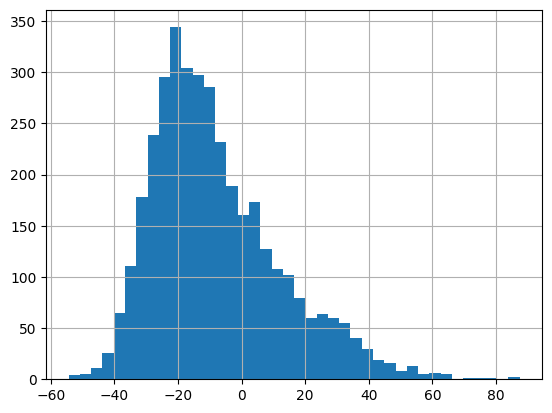

In [42]:
sdf['quality'].hist(bins = 40)

<Axes: xlabel='quality', ylabel='Count'>

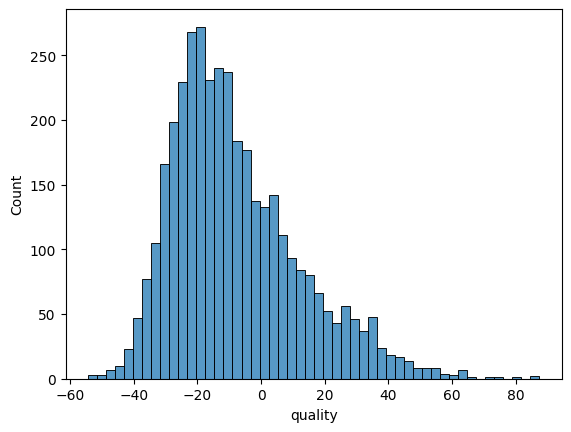

In [43]:
sns.histplot(data = sdf, x = 'quality', bins = 50)

## defense

In [44]:
# #the scores of the opponents in an alliance

def opp_scores(team_num, game_key):
    scores = []
    opps = df.loc[(df['key'] == game_key) & (df['alliance'] != df.loc[(df['key'] == game_key) & (df['team_number'] == team_num), 'alliance'].iloc[0])]
    for index, team in opps.iterrows():
        coralsWithDefense = team['teleopCoralCount']
        coralsWithoutDefense = (sdf.at[team['team_number'], 'teleopReef_tba_botRowCount'] + 
                                sdf.at[team['team_number'], 'teleopReef_tba_midRowCount'] +
                                sdf.at[team['team_number'], 'teleopReef_tba_topRowCount'] +
                                sdf.at[team['team_number'], 'teleopReef_trough'])
        
        scores.append(coralsWithoutDefense - coralsWithDefense)
    if scores == []:
        scores = [0]
    return sum(scores)/len(scores)


In [45]:
#the average score of all opponents of team
def opp_team_games(team_num):
    game_keys = df.loc[df['team_number'] == team_num]['key']
    averages = []
    for i in game_keys:
        averages.append(opp_scores(team_num, i))
    
    return sum(averages)/len(averages)

In [46]:
opp_scores('frc2231','2025isde4_qm36')

np.float64(-1.6097253716301338)

In [47]:
df.loc[df['key'] == '2025isde4_qm36']

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
5492,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,False,False,True,2.0,0.0,frc1577,127.0,1,red
24889,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,False,False,True,2.0,0.0,frc2231,127.0,2,red
44286,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,False,False,True,2.0,0.0,frc6738,127.0,3,red
63683,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,True,True,True,1.0,0.0,frc4320,114.0,1,blue
83080,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,True,True,True,1.0,0.0,frc1954,114.0,2,blue
102477,1.741705e+09,qm,2025isde4,2025isde4_qm36,36,1.741705e+09,1,1.741704e+09,"[{'key': '0KTgbwt9DqM', 'type': 'youtube'}]",red,...,False,True,True,True,1.0,0.0,frc5291,114.0,3,blue


In [48]:
opp_team_games('frc2679')

np.float64(5.4135388290957405)

In [49]:
opp_team_games('frc7067')

np.float64(4.3488308610217805)

In [50]:
opp_team_games('frc1574')

np.float64(2.85690506974724)

In [51]:
opp_team_games('frc1690')

np.float64(-2.434157770725551)

In [52]:
opp_team_games('frc1580')

np.float64(4.729591156943446)

In [53]:
for team in sdf.index:
    sdf.at[team,'defense'] = float(opp_team_games(team))

KeyboardInterrupt: 

In [ ]:
sdf.sort_values(by = 'defense', ascending=False)

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,...,teleopReef_trough,wallAlgaeCount,endGame,possition,games,quality,std,min,max,defense
frc8751,63.333333,0.750000,0.000000,0.000000,0.583333,0.083333,0.583333,1.750000,0.916667,1.833333,...,2.916667,1.583333,Parked,1.0,['2025casj_qm34' '2025casj_qm67' '2025casj_qm7...,-40.729149,22.592571,31.0,101.0,7.747601
frc7760,73.250000,1.000000,0.000000,0.000000,0.500000,0.000000,0.083333,1.833333,0.583333,0.166667,...,1.666667,0.750000,Nothing,1.0,['2025mefal_qm44' '2025mefal_qm47' '2025mefal_...,-42.478630,20.407663,37.0,111.0,7.140067
frc9453,70.033333,0.866667,0.033333,0.033333,0.833333,0.533333,0.200000,1.433333,0.400000,1.033333,...,4.433333,0.266667,Parked,3.0,['2025inkok_qm68' '2025inmis_qm15' '2025inmis_...,-38.618148,38.736496,23.0,150.0,6.849830
frc9772,70.363636,0.818182,0.000000,0.000000,0.545455,0.590909,0.409091,2.000000,1.227273,1.181818,...,1.818182,0.363636,Parked,2.0,['2025caph_qm20' '2025cave_qm34' '2025cave_qm4...,-33.071775,31.136482,22.0,143.0,6.776437
frc5760,79.500000,1.000000,0.083333,0.000000,1.000000,0.250000,0.250000,1.500000,1.916667,1.500000,...,2.333333,0.583333,Parked,1.0,['2025camb_qm2' '2025camb_qm32' '2025camb_qm63...,-39.385061,47.578643,11.0,162.0,6.664274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc1625,155.925000,0.975000,0.100000,0.150000,2.800000,0.275000,0.100000,4.550000,0.225000,4.225000,...,2.475000,0.950000,DeepCage,3.0,['2025gal_qm4' '2025gal_qm61' '2025iacf_qm19' ...,33.613387,51.018542,73.0,245.0,-4.643412
frc2056,229.741573,1.000000,0.033708,0.292135,6.292135,0.191011,0.640449,7.741573,0.348315,9.730337,...,7.808989,1.056180,DeepCage,1.0,['2025cmptx_sf4m1' '2025dal_qm91' '2025iri_qm4...,87.308111,41.709925,131.0,321.0,-4.836651
frc6358,157.173913,1.000000,0.652174,0.086957,2.260870,0.521739,0.000000,3.304348,0.130435,6.695652,...,4.173913,1.260870,Parked,3.0,['2025arc_qm112' '2025arc_qm24' '2025idbo_qm51...,30.769639,53.628903,51.0,248.0,-4.957987
frc2910,217.232877,1.000000,0.342466,0.849315,4.616438,0.287671,0.068493,5.424658,0.315068,9.383562,...,7.726027,1.178082,DeepCage,1.0,['2025cmptx_sf11m1' '2025cmptx_sf13m1' '2025cm...,79.624214,57.944303,95.0,301.0,-5.333829


<Axes: >

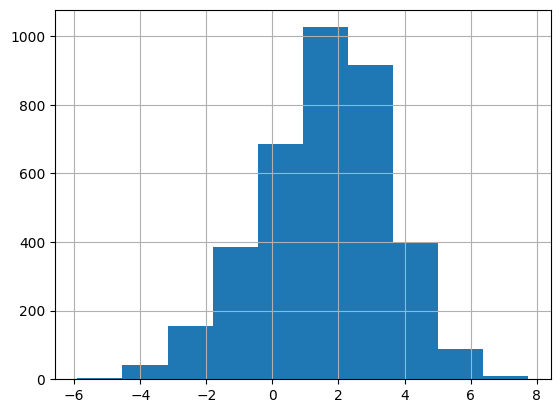

In [ ]:
sdf['defense'].hist()

<Axes: xlabel='defense', ylabel='Count'>

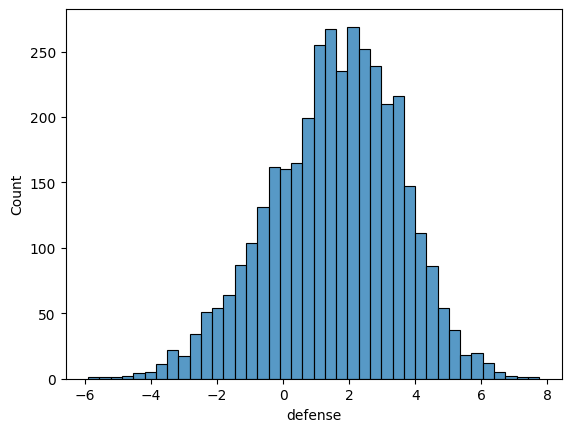

In [ ]:
sns.histplot(data = sdf, x = 'defense')

## the two other columns

<Axes: >

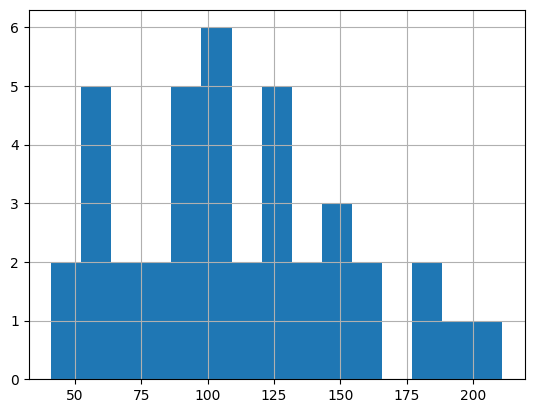

In [ ]:
df.loc[df['team_number'] == 'frc3211']['score'].hist(bins=15)

In [ ]:
df.loc[df['team_number'] == 'frc3211']['score'].kurt()

np.float64(-0.3421938767674644)

In [ ]:
df.loc[df['team_number'] == 'frc3211']['score'].skew()

np.float64(0.4319133416291086)

In [ ]:
df['team_number'].unique()

array(['frc2783', 'frc5045', 'frc538', ..., 'frc4972', 'frc8500',
       'frc5019'], shape=(3722,), dtype=object)

## task 49

In [ ]:
def iqr_outliers (team):
    data = df.loc[df['team_number'] == team]

    Q1 = data['score'].quantile(0.25)
    Q3 = data['score'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data['score'] < lower) | (data['score'] > upper)]
    return outliers


In [ ]:
iqr_outliers('frc1574')

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance


In [ ]:
outliers_df = pd.DataFrame()
for i in sdf.index:
    outliers_df = pd.concat([outliers_df, iqr_outliers(i)])

In [ ]:
outliers_df

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
19435,1.741985e+09,qm,2025alhu,2025alhu_qm42,42,1.741985e+09,1,1.741984e+09,"[{'key': '-OXjpkKLwek', 'type': 'youtube'}]",red,...,True,True,False,False,1.0,2.0,frc8624,117.0,2,red
61572,1.743866e+09,qm,2025flwp,2025flwp_qm70,70,1.743867e+09,1,1.743866e+09,"[{'key': 'Z9KmXb4e6ps', 'type': 'youtube'}]",blue,...,True,True,True,True,0.0,3.0,frc744,191.0,1,blue
34,1.741983e+09,qm,2025alhu,2025alhu_qm39,39,1.741983e+09,1,1.741983e+09,"[{'key': 'uwfPTIh3c6Y', 'type': 'youtube'}]",red,...,True,True,True,True,6.0,5.0,frc325,192.0,1,red
110824,1.746897e+09,qm,2025ohsc,2025ohsc_qm24,24,1.746897e+09,1,1.746893e+09,[],blue,...,True,True,True,True,0.0,2.0,frc325,185.0,3,blue
58255,1.741998e+09,qm,2025alhu,2025alhu_qm66,66,1.741998e+09,1,1.742050e+09,"[{'key': 'W_ofKXA7u-Y', 'type': 'youtube'}]",blue,...,True,True,True,True,0.0,4.0,frc2190,166.0,1,blue
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55411,1.741176e+09,qm,2025tuis2,2025tuis2_qm31,31,1.741176e+09,1,1.741175e+09,"[{'key': 'orn5vPeTRmo', 'type': 'youtube'}]",red,...,False,True,False,True,4.0,1.0,frc10608,82.0,3,red
55506,1.741441e+09,qm,2025tuis3,2025tuis3_qm38,38,1.741441e+09,1,1.741440e+09,[],red,...,True,True,True,True,5.0,0.0,frc7086,163.0,3,red
36108,1.741440e+09,qm,2025tuis3,2025tuis3_qm37,37,1.741440e+09,1,1.741440e+09,"[{'key': 'ccA0n1qnbmw', 'type': 'youtube'}]",red,...,False,False,False,False,0.0,0.0,frc4972,15.0,2,red
113691,1.741438e+09,qm,2025tuis3,2025tuis3_qm32,32,1.741438e+09,1,1.741437e+09,"[{'key': 'RLLYM4v_R80', 'type': 'youtube'}]",blue,...,True,True,True,True,2.0,0.0,frc4972,80.0,3,blue


In [ ]:
df

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
0,1.742056e+09,f,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",blue,...,True,False,False,True,0.0,0.0,frc2783,124.0,1,red
1,1.742058e+09,f,2025alhu,2025alhu_f1m2,2,1.742058e+09,1,1.742057e+09,"[{'key': '1FpcfKgS3kw', 'type': 'youtube'}]",blue,...,True,True,True,False,0.0,0.0,frc2783,144.0,1,red
2,1.741960e+09,qm,2025alhu,2025alhu_qm1,1,1.741960e+09,1,1.741960e+09,"[{'key': 'mAbsfvQlhaw', 'type': 'youtube'}]",red,...,False,False,False,False,5.0,2.0,frc5045,129.0,1,red
3,1.741965e+09,qm,2025alhu,2025alhu_qm10,10,1.741965e+09,1,1.741965e+09,"[{'key': 'xrkAU-qZY-E', 'type': 'youtube'}]",red,...,True,True,True,True,1.0,0.0,frc538,112.0,1,red
4,1.741965e+09,qm,2025alhu,2025alhu_qm11,11,1.741965e+09,1,1.741965e+09,"[{'key': 'ae-lJ4geVPg', 'type': 'youtube'}]",blue,...,False,True,True,True,1.0,1.0,frc6107,61.0,1,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116377,1.752379e+09,sf,2025xxmel,2025xxmel_sf5m1,1,1.752379e+09,5,1.752378e+09,[],red,...,False,False,False,False,6.0,0.0,frc9995,64.0,3,blue
116378,1.752379e+09,sf,2025xxmel,2025xxmel_sf6m1,1,1.752379e+09,6,1.752379e+09,[],blue,...,False,False,False,False,1.0,0.0,frc9991,72.0,3,blue
116379,1.752380e+09,sf,2025xxmel,2025xxmel_sf7m1,1,1.752380e+09,7,1.752380e+09,[],red,...,False,False,False,False,0.0,0.0,frc9994,65.0,3,blue
116380,1.752380e+09,sf,2025xxmel,2025xxmel_sf8m1,1,1.752380e+09,8,1.752381e+09,[],red,...,False,True,True,True,14.0,0.0,frc9993,73.0,3,blue


In [ ]:
sdf.at['frc1580', 'quality']

np.float64(-46.94625611668398)

In [ ]:
sdf.at['frc1574', 'quality']

np.float64(7.927856470025233)

In [ ]:
df.drop(outliers_df.index, inplace = True)

## min, max and std

In [ ]:
sdf

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,games,quality
frc2783,139.357143,1.000000,0.000000,0.023810,3.500000,0.214286,0.285714,2.309524,0.261905,3.166667,5.976190,9.785714,1.119048,1.428571,DeepCage,1.0,['2025alhu_f1m1' '2025alhu_f1m2' '2025alhu_qm3...,21.265677
frc5045,85.000000,0.909091,0.000000,0.136364,1.000000,0.727273,0.318182,1.363636,0.409091,1.000000,2.636364,5.545455,2.863636,1.500000,Parked,1.0,['2025alhu_qm1' '2025alhu_qm16' '2025tnkn_qm1'...,-17.440729
frc538,78.238095,0.809524,0.095238,0.047619,1.000000,0.238095,0.190476,1.523810,0.333333,1.476190,2.238095,5.333333,1.761905,1.190476,Parked,3.0,['2025alhu_qm10' '2025alhu_qm21' '2025tnkn_qm2...,-23.862662
frc6107,81.714286,0.952381,0.285714,0.142857,0.666667,0.523810,0.095238,1.857143,0.238095,2.142857,2.952381,3.904762,1.523810,1.809524,Parked,1.0,['2025alhu_qm11' '2025alhu_qm26' '2025alhu_qm3...,-20.894306
frc8624,50.909091,0.818182,0.000000,0.000000,0.272727,0.000000,0.000000,1.363636,1.454545,1.090909,0.727273,2.636364,1.454545,0.454545,Parked,2.0,['2025alhu_qm12' '2025alhu_qm75' '2025alhu_qm4...,-43.753949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc7086,74.666667,1.000000,0.083333,0.000000,1.083333,0.083333,0.833333,0.416667,0.250000,3.083333,2.833333,5.416667,1.666667,0.166667,Parked,2.0,['2025tuis3_qm21' '2025tuis3_sf12m1' '2025tuis...,-8.632482
frc10180,69.200000,1.000000,0.000000,0.000000,0.400000,0.400000,0.200000,0.700000,2.000000,1.000000,1.000000,1.800000,3.500000,2.900000,DeepCage,2.0,['2025tuis3_qm27' '2025tuis3_qm59' '2025tuis3_...,-3.744406
frc4972,49.100000,0.800000,0.000000,0.000000,0.400000,0.500000,0.200000,0.100000,0.700000,0.900000,0.500000,4.500000,2.600000,0.000000,Parked,2.0,['2025tuis3_qm37' '2025tuis3_qm67' '2025tuis3_...,-23.179094
frc8500,44.000000,0.500000,0.000000,0.000000,0.375000,0.250000,0.750000,0.375000,0.500000,0.750000,1.125000,2.125000,2.125000,0.000000,Nothing,2.0,['2025tuis3_qm39' '2025tuis3_qm44' '2025tuis3_...,-19.743244


In [ ]:
scores = df.loc[df['team_number'] == 'frc1574']['score']
score_val = scores.describe()
score_val

count     47.000000
mean     129.340426
std       36.091235
min       60.000000
25%       97.500000
50%      129.000000
75%      154.500000
max      199.000000
Name: score, dtype: float64

In [ ]:
for team in sdf.index:
    scores = df.loc[df['team_number'] == team]['score']
    score_val = scores.describe()
    sdf.at[team, 'std'] = score_val['std']
    sdf.at[team, 'min'] = score_val['min']
    sdf.at[team, 'max'] = score_val['max']



In [ ]:
sdf

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,...,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,games,quality,std,min,max
frc2783,139.357143,1.000000,0.000000,0.023810,3.500000,0.214286,0.285714,2.309524,0.261905,3.166667,...,9.785714,1.119048,1.428571,DeepCage,1.0,['2025alhu_f1m1' '2025alhu_f1m2' '2025alhu_qm3...,21.265677,41.650592,60.0,232.0
frc5045,85.000000,0.909091,0.000000,0.136364,1.000000,0.727273,0.318182,1.363636,0.409091,1.000000,...,5.545455,2.863636,1.500000,Parked,1.0,['2025alhu_qm1' '2025alhu_qm16' '2025tnkn_qm1'...,-17.440729,35.079502,17.0,157.0
frc538,78.238095,0.809524,0.095238,0.047619,1.000000,0.238095,0.190476,1.523810,0.333333,1.476190,...,5.333333,1.761905,1.190476,Parked,3.0,['2025alhu_qm10' '2025alhu_qm21' '2025tnkn_qm2...,-23.862662,37.113212,17.0,154.0
frc6107,81.714286,0.952381,0.285714,0.142857,0.666667,0.523810,0.095238,1.857143,0.238095,2.142857,...,3.904762,1.523810,1.809524,Parked,1.0,['2025alhu_qm11' '2025alhu_qm26' '2025alhu_qm3...,-20.894306,37.698996,26.0,180.0
frc8624,50.909091,0.818182,0.000000,0.000000,0.272727,0.000000,0.000000,1.363636,1.454545,1.090909,...,2.636364,1.454545,0.454545,Parked,2.0,['2025alhu_qm12' '2025alhu_qm75' '2025alhu_qm4...,-43.753949,16.606893,19.0,72.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
frc7086,74.666667,1.000000,0.083333,0.000000,1.083333,0.083333,0.833333,0.416667,0.250000,3.083333,...,5.416667,1.666667,0.166667,Parked,2.0,['2025tuis3_qm21' '2025tuis3_sf12m1' '2025tuis...,-8.632482,24.196919,32.0,103.0
frc10180,69.200000,1.000000,0.000000,0.000000,0.400000,0.400000,0.200000,0.700000,2.000000,1.000000,...,1.800000,3.500000,2.900000,DeepCage,2.0,['2025tuis3_qm27' '2025tuis3_qm59' '2025tuis3_...,-3.744406,26.097254,37.0,116.0
frc4972,49.100000,0.800000,0.000000,0.000000,0.400000,0.500000,0.200000,0.100000,0.700000,0.900000,...,4.500000,2.600000,0.000000,Parked,2.0,['2025tuis3_qm37' '2025tuis3_qm67' '2025tuis3_...,-23.179094,15.116216,25.0,77.0
frc8500,44.000000,0.500000,0.000000,0.000000,0.375000,0.250000,0.750000,0.375000,0.500000,0.750000,...,2.125000,2.125000,0.000000,Nothing,2.0,['2025tuis3_qm39' '2025tuis3_qm44' '2025tuis3_...,-19.743244,26.482699,8.0,86.0


In [ ]:
sdf.drop(['frc9990', 'frc9991', 'frc9992', 'frc9993', 'frc9994', 'frc9995', 'frc9996', 'frc9997', 'frc9998', 'frc9999'], axis = 0, inplace = True)

In [ ]:
teams_to_drop = ['frc9990', 'frc9991', 'frc9992', 'frc9993', 'frc9994', 'frc9995', 'frc9996', 'frc9997', 'frc9998', 'frc9999']
df = df[~df['team_number'].isin(teams_to_drop)]

In [ ]:
df

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
0,1.742056e+09,f,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",blue,...,True,False,False,True,0.0,0.0,frc2783,124.0,1,red
1,1.742058e+09,f,2025alhu,2025alhu_f1m2,2,1.742058e+09,1,1.742057e+09,"[{'key': '1FpcfKgS3kw', 'type': 'youtube'}]",blue,...,True,True,True,False,0.0,0.0,frc2783,144.0,1,red
2,1.741960e+09,qm,2025alhu,2025alhu_qm1,1,1.741960e+09,1,1.741960e+09,"[{'key': 'mAbsfvQlhaw', 'type': 'youtube'}]",red,...,False,False,False,False,5.0,2.0,frc5045,129.0,1,red
3,1.741965e+09,qm,2025alhu,2025alhu_qm10,10,1.741965e+09,1,1.741965e+09,"[{'key': 'xrkAU-qZY-E', 'type': 'youtube'}]",red,...,True,True,True,True,1.0,0.0,frc538,112.0,1,red
4,1.741965e+09,qm,2025alhu,2025alhu_qm11,11,1.741965e+09,1,1.741965e+09,"[{'key': 'ae-lJ4geVPg', 'type': 'youtube'}]",blue,...,False,True,True,True,1.0,1.0,frc6107,61.0,1,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116366,1.752281e+09,qm,2025xxmel,2025xxmel_qm7,7,1.752281e+09,1,1.752280e+09,[],red,...,False,False,False,False,8.0,0.0,frc7128,66.0,3,blue
116368,1.752282e+09,qm,2025xxmel,2025xxmel_qm9,9,1.752283e+09,1,1.752281e+09,[],blue,...,False,False,False,False,9.0,0.0,frc6996,91.0,3,blue
116369,1.752382e+09,sf,2025xxmel,2025xxmel_sf10m1,1,1.752382e+09,10,1.752382e+09,[],red,...,False,True,True,True,9.0,0.0,frc5648,70.0,3,blue
116370,1.752382e+09,sf,2025xxmel,2025xxmel_sf11m1,1,1.752383e+09,11,1.752383e+09,[],red,...,True,False,True,True,6.0,0.0,frc10002,90.0,3,blue


In [ ]:
sdf